# Thesis Baseline Setup

This notebook documents the workflow for the thesis baseline on xBD/xView2 using a building-level classification pipeline.

---

## Core Principle

- Preprocessing and model training run directly in Python
- Notebook is used for:
  - Data inspection
  - Sanity checks
  - Training control
  - Evaluation
  - Visualization

The official xView2 Docker pipeline is not used as the main experimental setup, because the thesis isolates the damage classification task from localization by using ground truth building polygons.

---

## Required Data

Download and place on Desktop:

- `train`
- `test`
- `hold`

These contain:
- images
- labels

---

## Main Experimental Design

The thesis does not use the original end to end competition pipeline as the primary method.

Instead, the pipeline is:

1. Read ground truth polygons from label JSON files
2. Build a building-level metadata table
3. Extract pre/post building crops
4. Stack pre and post crops into 6-channel tensors
5. Train a ResNet50-based classifier on damage labels

This removes localization as a confounding factor and isolates the classification task.

---

## Required External Apps

- `miniconda` or another Python environment manager


## Create Environment

```bash
conda create -n thesis_xview python=3.10
conda activate thesis_xview

python --version
which python

python -m pip install --upgrade pip setuptools wheel

python -m pip install -r requirements.txt

python -m ipykernel install --user --name thesis_xview --display-name "Python thesis_xview" '''


## Create Environment

```bash
conda create -n thesis_xview python=3.10
conda activate thesis_xview

python --version
which python

python -m pip install --upgrade pip setuptools wheel

python -m pip install -r requirements.txt

python -m ipykernel install --user --name thesis_xview --display-name "Python thesis_xview"
```

## Restart Kernel

Restart VS Code or Jupyter, then select the new kernel:

```text
Python thesis_xview
```

from:

```text
Kernel → Change Kernel → thesis_xview
```

## Load Packages

In [ ]:
import sys
!{sys.executable} -m pip install -r requirements.txt

In [ ]:
import sys
import torch
import torchvision

print(sys.executable)
print(sys.version)
print(torch.__version__)
print(torchvision.__version__)
print("MPS available:", torch.backends.mps.is_available())

## Run the model

In [10]:
import sys
!{sys.executable} model/classification_baseline.py

Seed 123 | Epoch 4/8: 100%|████| 4994/4994 [31:41<00:00,  2.63it/s, loss=0.4268]
Seed 123 | Epoch 04 | Train Loss: 0.2822 | Val Loss: 0.3968 | Val Macro F1: 0.7034 | Time: 34.30 min
Seed 123 | Epoch 5/8: 100%|████| 4994/4994 [25:36<00:00,  3.25it/s, loss=0.1194]
Seed 123 | Epoch 05 | Train Loss: 0.2138 | Val Loss: 0.4669 | Val Macro F1: 0.6993 | Time: 28.04 min
Seed 123 | Epoch 6/8: 100%|████| 4994/4994 [24:45<00:00,  3.36it/s, loss=0.1564]
Seed 123 | Epoch 06 | Train Loss: 0.1550 | Val Loss: 0.5047 | Val Macro F1: 0.6869 | Time: 27.15 min
Seed 123 | Epoch 7/8: 100%|████| 4994/4994 [24:16<00:00,  3.43it/s, loss=0.3657]
Seed 123 | Epoch 07 | Train Loss: 0.1148 | Val Loss: 0.5725 | Val Macro F1: 0.6806 | Time: 26.60 min
Seed 123 | Epoch 8/8: 100%|████| 4994/4994 [24:19<00:00,  3.42it/s, loss=0.0653]
Seed 123 | Epoch 08 | Train Loss: 0.0926 | Val Loss: 0.5920 | Val Macro F1: 0.6760 | Time: 26.65 min

Starting unweighted baseline seed 999

Using unweighted cross entropy.

Starting training

## Check Confidence Intervals

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import t

# ============================================================
# Configuration
# ============================================================

BASE_DIR = Path.home() / "Desktop"

# Change this folder depending on the model you want to evaluate
RESULTS_DIR = BASE_DIR / "training_outputs" / "unweighted_baseline_resnet50_5seeds_1se"

FINAL_RESULTS_PATH = RESULTS_DIR / "final_results_by_seed_selected_1se.csv"
PER_CLASS_PATH = RESULTS_DIR / "all_seed_per_class_metrics_selected_1se.csv"
PER_ENV_PATH = RESULTS_DIR / "all_seed_per_environment_metrics_selected_1se.csv"

OUTPUT_DIR = RESULTS_DIR / "confidence_intervals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIDENCE_LEVEL = 0.95


# ============================================================
# Helper function
# ============================================================

def compute_t_confidence_interval(values, confidence_level=0.95):
    values = pd.Series(values).dropna().astype(float)
    n = len(values)

    if n < 2:
        return {
            "n": n,
            "mean": float(values.mean()) if n == 1 else np.nan,
            "std": np.nan,
            "se": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "margin": np.nan,
        }

    mean = values.mean()
    std = values.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence_level
    t_value = t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_value * se

    return {
        "n": int(n),
        "mean": float(mean),
        "std": float(std),
        "se": float(se),
        "ci_lower": float(mean - margin),
        "ci_upper": float(mean + margin),
        "margin": float(margin),
    }


def summarize_metrics(df, metric_columns, confidence_level=0.95):
    rows = []

    for metric in metric_columns:
        if metric not in df.columns:
            print(f"Skipping missing metric: {metric}")
            continue

        stats = compute_t_confidence_interval(
            df[metric],
            confidence_level=confidence_level,
        )

        rows.append({
            "metric": metric,
            **stats,
        })

    return pd.DataFrame(rows)


# ============================================================
# 1. Model-level confidence intervals
# ============================================================

final_df = pd.read_csv(FINAL_RESULTS_PATH)

model_metric_columns = [
    "val_macro_f1",
    "hold_macro_f1",
    "val_loss",
    "hold_loss",
    "val_f1_no_damage",
    "val_f1_minor",
    "val_f1_major",
    "val_f1_destroyed",
    "hold_f1_no_damage",
    "hold_f1_minor",
    "hold_f1_major",
    "hold_f1_destroyed",
]

model_ci = summarize_metrics(
    final_df,
    model_metric_columns,
    confidence_level=CONFIDENCE_LEVEL,
)

model_ci.to_csv(
    OUTPUT_DIR / "model_level_95_confidence_intervals.csv",
    index=False,
)

print("\nModel-level 95% confidence intervals:")
display(model_ci.round(4))


# ============================================================
# 2. Per-class confidence intervals
# ============================================================

if PER_CLASS_PATH.exists():
    per_class_df = pd.read_csv(PER_CLASS_PATH)

    per_class_rows = []

    for (split, class_id, class_name), group in per_class_df.groupby(
        ["split", "class_id", "class_name"]
    ):
        stats = compute_t_confidence_interval(
            group["f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_class_rows.append({
            "split": split,
            "class_id": class_id,
            "class_name": class_name,
            "metric": "f1",
            **stats,
        })

    per_class_ci = pd.DataFrame(per_class_rows)

    per_class_ci.to_csv(
        OUTPUT_DIR / "per_class_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-class 95% confidence intervals:")
    display(per_class_ci.round(4))

else:
    print(f"\nPer-class file not found: {PER_CLASS_PATH}")


# ============================================================
# 3. Per-environment confidence intervals
# ============================================================

if PER_ENV_PATH.exists():
    per_env_df = pd.read_csv(PER_ENV_PATH)

    per_env_rows = []

    for (split, environment), group in per_env_df.groupby(
        ["split", "environment"]
    ):
        stats = compute_t_confidence_interval(
            group["macro_f1"],
            confidence_level=CONFIDENCE_LEVEL,
        )

        per_env_rows.append({
            "split": split,
            "environment": environment,
            "metric": "macro_f1",
            **stats,
        })

    per_env_ci = pd.DataFrame(per_env_rows)

    per_env_ci.to_csv(
        OUTPUT_DIR / "per_environment_95_confidence_intervals.csv",
        index=False,
    )

    print("\nPer-environment 95% confidence intervals:")
    display(per_env_ci.round(4))

else:
    print(f"\nPer-environment file not found: {PER_ENV_PATH}")



print("\nSaved confidence interval outputs to:")
print(OUTPUT_DIR)


Model-level 95% confidence intervals:


,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,val_macro_f1,5,0.7107,0.0029,0.0013,0.7072,0.7143,0.0036
1,hold_macro_f1,5,0.7143,0.0077,0.0034,0.7048,0.7238,0.0095
2,val_loss,5,0.3886,0.0139,0.0062,0.3713,0.4058,0.0173
3,hold_loss,5,0.4380,0.0090,0.0040,0.4268,0.4492,0.0112
4,val_f1_no_damage,5,0.9358,0.0015,0.0007,0.9339,0.9377,0.0019
5,val_f1_minor,5,0.5870,0.0101,0.0045,0.5745,0.5995,0.0125
6,val_f1_major,5,0.5501,0.0086,0.0038,0.5394,0.5607,0.0107
7,val_f1_destroyed,5,0.7700,0.0050,0.0022,0.7638,0.7763,0.0062
8,hold_f1_no_damage,5,0.9215,0.0012,0.0005,0.9200,0.9229,0.0014
9,hold_f1_minor,5,0.6032,0.0165,0.0074,0.5827,0.6237,0.0205



Per-class 95% confidence intervals:


,split,class_id,class_name,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,hold,0,no-damage,f1,5,0.9215,0.0012,0.0005,0.9200,0.9229,0.0014
1,hold,1,minor-damage,f1,5,0.6032,0.0165,0.0074,0.5827,0.6237,0.0205
2,hold,2,major-damage,f1,5,0.5706,0.0155,0.0069,0.5514,0.5899,0.0193
3,hold,3,destroyed,f1,5,0.7620,0.0082,0.0037,0.7519,0.7722,0.0102
4,validation,0,no-damage,f1,5,0.9358,0.0015,0.0007,0.9339,0.9377,0.0019
5,validation,1,minor-damage,f1,5,0.5870,0.0101,0.0045,0.5745,0.5995,0.0125
6,validation,2,major-damage,f1,5,0.5501,0.0086,0.0038,0.5394,0.5607,0.0107
7,validation,3,destroyed,f1,5,0.7700,0.0050,0.0022,0.7638,0.7763,0.0062



Per-environment 95% confidence intervals:


,split,environment,metric,n,mean,std,se,ci_lower,ci_upper,margin
0,hold,guatemala-volcano,macro_f1,5,0.3210,0.0266,0.0119,0.2880,0.3540,0.0330
1,hold,hurricane-florence,macro_f1,5,0.4306,0.0201,0.0090,0.4057,0.4555,0.0249
2,hold,hurricane-harvey,macro_f1,5,0.4026,0.0149,0.0066,0.3842,0.4211,0.0184
3,hold,hurricane-matthew,macro_f1,5,0.4794,0.0187,0.0083,0.4562,0.5026,0.0232
4,hold,hurricane-michael,macro_f1,5,0.5404,0.0125,0.0056,0.5248,0.5560,0.0156
5,hold,mexico-earthquake,macro_f1,5,0.2489,0.0003,0.0001,0.2485,0.2492,0.0003
6,hold,midwest-flooding,macro_f1,5,0.4412,0.0358,0.0160,0.3967,0.4856,0.0444
7,hold,palu-tsunami,macro_f1,5,0.4497,0.0143,0.0064,0.4319,0.4674,0.0178
8,hold,santa-rosa-wildfire,macro_f1,5,0.4928,0.0080,0.0036,0.4828,0.5027,0.0099
9,hold,socal-fire,macro_f1,5,0.4437,0.0108,0.0049,0.4302,0.4572,0.0135



Saved confidence interval outputs to:
/Users/paolo/Desktop/training_outputs/unweighted_baseline_resnet50_5seeds_1se/confidence_intervals


## Confusion Matrix


Loaded rows: 265685

Seeds loaded:
[42, 123, 999, 2024, 2025]

Rows per seed:
seed
42      53137
123     53137
999     53137
2024    53137
2025    53137
Name: count, dtype: int64

Pooled normalized confusion matrix:

              no-damage  minor-damage  major-damage  destroyed
no-damage         0.940         0.029         0.018      0.012
minor-damage      0.300         0.550         0.115      0.035
major-damage      0.282         0.107         0.546      0.065
destroyed         0.147         0.033         0.061      0.760


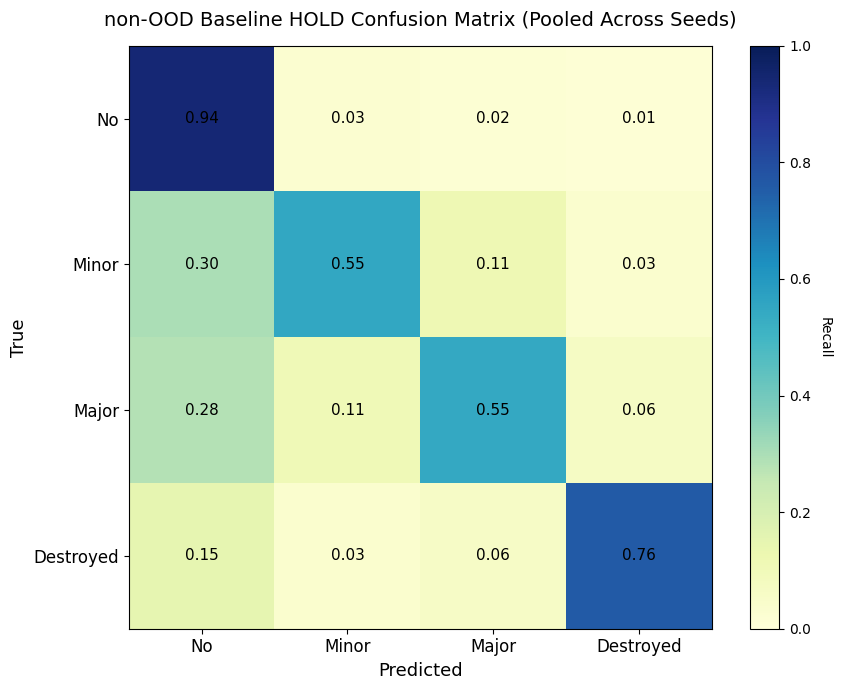

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# ============================================================
# Configuration
# ============================================================

SEEDS = [42, 123, 999, 2024, 2025]

labels = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

short_labels = [
    "No",
    "Minor",
    "Major",
    "Destroyed",
]

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

# ============================================================
# Load all seed prediction files
# ============================================================

dfs = []

for seed in SEEDS:

    pred_path = (
        BASE_DIR
        / f"seed_{seed}"
        / "hold_predictions_selected_1se.csv"
    )

    if not pred_path.exists():
        raise FileNotFoundError(
            f"Missing prediction file: {pred_path}"
        )

    df_seed = pd.read_csv(pred_path)

    df_seed["seed"] = seed

    dfs.append(df_seed)

# ============================================================
# Concatenate all predictions
# ============================================================

df = pd.concat(dfs, ignore_index=True)

print("\nLoaded rows:", len(df))

print("\nSeeds loaded:")
print(sorted(df["seed"].unique()))

print("\nRows per seed:")
print(df["seed"].value_counts().sort_index())

# ============================================================
# True / predicted labels
# ============================================================

y_true = df["target_id"]
y_pred = df["pred_id"]

# ============================================================
# Overall pooled confusion matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3],
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

print("\nPooled normalized confusion matrix:\n")

print(
    pd.DataFrame(
        cm_norm,
        index=labels,
        columns=labels,
    ).round(3)
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    cm_norm,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(im, ax=ax)

cbar.ax.set_ylabel(
    "Recall",
    rotation=270,
    labelpad=15,
)

# ============================================================
# Axis labels
# ============================================================

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(
    short_labels,
    fontsize=12,
)

ax.set_yticklabels(
    short_labels,
    fontsize=12,
)

ax.set_xlabel(
    "Predicted",
    fontsize=13,
)

ax.set_ylabel(
    "True",
    fontsize=13,
)

ax.set_title(
    "non-OOD Baseline HOLD Confusion Matrix (Pooled Across Seeds)",
    fontsize=14,
    pad=15,
)

# ============================================================
# Cell annotations
# ============================================================

for i in range(cm_norm.shape[0]):

    for j in range(cm_norm.shape[1]):

        ax.text(
            j,
            i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="black",
        )

# ============================================================
# Final layout
# ============================================================

plt.tight_layout()
plt.show()

## Actual vs Predicted

Available splits:
split
train    159793
test      53850
hold      53137
Name: count, dtype: int64

Rows in selected split: 53137
Rows in prediction file: 53137

Number of available images: 751

First available image IDs:
image_id
palu-tsunami_00000089         922
mexico-earthquake_00000167    859
palu-tsunami_00000095         822
mexico-earthquake_00000162    699
palu-tsunami_00000017         690
Name: count, dtype: int64

Selected image_id: hurricane-harvey_00000417
Number of buildings in selected image: 186


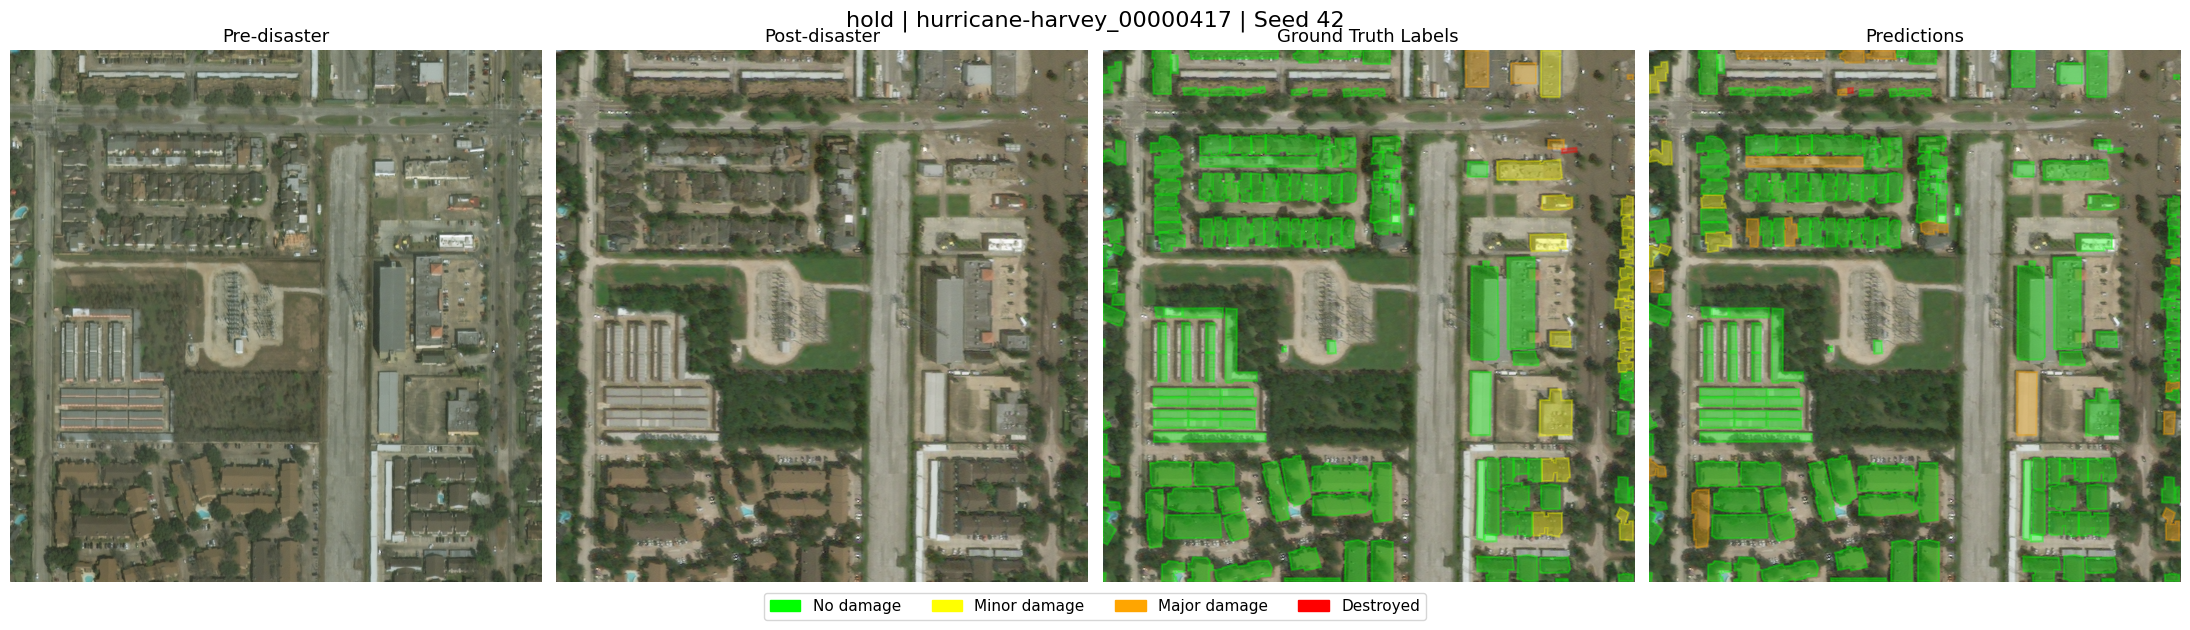

In [6]:
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Configuration
# =========================

SEED = 42
CSV_SPLIT = "hold"

BASE_DIR = Path.home() / "Desktop"

CSV_PATH = (
    BASE_DIR
    / "processed"
    / "buildings_all_with_crops.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "training_outputs"
    / "unweighted_baseline_resnet50_5seeds_1se"
)

PRED_PATH = (
    OUTPUT_DIR
    / f"seed_{SEED}"
    / "hold_predictions_selected_1se.csv"
)

LABELS = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================

df = pd.read_csv(CSV_PATH)
pred_df = pd.read_csv(PRED_PATH)

print("Available splits:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

print("\nRows in selected split:", len(split_df))
print("Rows in prediction file:", len(pred_df))

if len(split_df) == 0:
    raise ValueError(f"No rows found for split: {CSV_SPLIT}")

if len(split_df) != len(pred_df):
    raise ValueError(
        f"Mismatch: CSV split has {len(split_df)} rows, "
        f"but prediction file has {len(pred_df)} rows."
    )

# =========================
# Add predictions
# =========================

split_df["pred_idx"] = pred_df["pred_id"].values
split_df["true_idx"] = pred_df["target_id"].values

split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================

counts = split_df["image_id"].value_counts()

print("\nNumber of available images:", len(counts))
print("\nFirst available image IDs:")
print(counts.head())

IMAGE_INDEX = 69

if IMAGE_INDEX >= len(counts):
    raise ValueError(
        f"IMAGE_INDEX={IMAGE_INDEX} is too large. "
        f"Maximum valid index is {len(counts) - 1}."
    )

image_id = counts.index[IMAGE_INDEX]
img_df = split_df[split_df["image_id"] == image_id].copy()

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================

pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================

def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )

        ax.add_patch(patch)

# =========================
# Legend
# =========================

legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster", fontsize=13)
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster", fontsize=13)
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=11,
)

plt.suptitle(
    f"{CSV_SPLIT} | {image_id} | Seed {SEED}",
    fontsize=16,
)

plt.tight_layout()
plt.show()